# K-Means Clustering for Street Segment Safety Classification
## London Urban Safety — Unsupervised Risk Classification

This notebook applies **PCA + K-Means clustering** to classify street segments into low / medium / high safety risk without labelled training data.

**Pipeline:**
1. Load & standardize features (same as PCA notebook)
2. Apply PCA for dimensionality reduction
3. Determine optimal k via elbow curve + silhouette score
4. Fit K-Means (k=3) in PCA space
5. Order clusters → assign low / medium / high labels
6. Visualize clusters in PCA space and feature space
7. Export classified segments

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
print('✓ All imports successful')

✓ All imports successful


## Step 1: Load & Standardize Features

In [15]:
FEATURE_COLS = [
    'lighting_norm', 'visibility_norm', 'connectivity_norm',
    'enclosure_norm', 'dominant_land_use_score_norm', 'public_transport_proximity_m_norm'
]

FEATURE_LABELS = {
    'lighting_norm': 'Lighting',
    'visibility_norm': 'Visibility',
    'connectivity_norm': 'Connectivity',
    'enclosure_norm': 'Enclosure',
    'dominant_land_use_score_norm': 'Land Use Score',
    'public_transport_proximity_m_norm': 'Transport Proximity'
}
clean_name = lambda col: FEATURE_LABELS.get(col, col.replace('_norm', ''))

csv_path = r'C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\segment_risk_scores_w-id.csv'
features = pd.read_csv(csv_path)
print(f'✓ Loaded {len(features):,} segments')

X = features[FEATURE_COLS].dropna()
print(f'Feature matrix shape: {X.shape}')

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('✓ Features standardized (mean=0, std=1)')

✓ Loaded 35,978 segments
Feature matrix shape: (35978, 6)
✓ Features standardized (mean=0, std=1)


## Step 2: Apply PCA

From the PCA notebook, 5 components explain ~96% of variance. We use that here to project into a lower-dimensional space before clustering — this reduces noise and handles feature heterogeneity.

In [16]:
# Fit full PCA to get variance breakdown
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumsum_explained = np.cumsum(explained_variance_ratio)

print('PCA Variance Breakdown:')
for i, (var, cum) in enumerate(zip(explained_variance_ratio, cumsum_explained)):
    print(f'  PC{i+1}: {var:.1%}  |  Cumulative: {cum:.1%}')

# Select n_components that explain >= 95% variance
n_components = int(np.argmax(cumsum_explained >= 0.95)) + 1
print(f'\n→ Using {n_components} components ({cumsum_explained[n_components-1]:.1%} variance explained)')

# Fit reduced PCA
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f'✓ PCA projection: {X_scaled.shape} → {X_pca.shape}')

PCA Variance Breakdown:
  PC1: 32.7%  |  Cumulative: 32.7%
  PC2: 21.8%  |  Cumulative: 54.5%
  PC3: 15.6%  |  Cumulative: 70.2%
  PC4: 13.9%  |  Cumulative: 84.1%
  PC5: 11.9%  |  Cumulative: 96.0%
  PC6: 4.0%  |  Cumulative: 100.0%

→ Using 5 components (96.0% variance explained)
✓ PCA projection: (35978, 6) → (35978, 5)


## Step 3: Determine Optimal k

Two complementary methods:
- **Elbow curve** (inertia): look for the point of diminishing returns
- **Silhouette score**: higher = better-defined clusters

We expect k=3 to be supported (low / medium / high), but let the data confirm it.

In [17]:
k_range = range(2, 9)
inertias = []
silhouette_scores = []

# Choose data for clustering: prefer raw numeric `risk_score` (1D) if present,
# otherwise fall back to PCA projection (`X_pca`). Align to the rows used in `X`.
if 'risk_score' in features.columns:
    risk_numeric = pd.to_numeric(features.loc[X.index, 'risk_score'], errors='coerce')
    if risk_numeric.isna().all():
        data_for_k = X_pca
        data_name = 'PCA'
    else:
        data_for_k = risk_numeric.values.reshape(-1, 1)
        data_name = 'risk_score'
else:
    data_for_k = X_pca
    data_name = 'PCA'

print(f'Computing K-Means for k = 2 … 8 on {data_name} (this may take a moment)...')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(data_for_k)
    inertias.append(km.inertia_)
    # silhouette_score requires >1 sample per cluster; use try/except to be robust
    try:
        sil = silhouette_score(data_for_k, labels, sample_size=5000, random_state=RANDOM_STATE)
    except Exception:
        sil = np.nan
    silhouette_scores.append(sil)
    print(f'  k={k}: inertia={km.inertia_:,.0f}  silhouette={sil if not np.isnan(sil) else "nan"}')

print('\n✓ Done')

Computing K-Means for k = 2 … 8 on risk_score (this may take a moment)...
  k=2: inertia=191  silhouette=0.55102952423417
  k=3: inertia=102  silhouette=0.527290374413004
  k=4: inertia=64  silhouette=0.5165735597254599
  k=5: inertia=44  silhouette=0.5192877899179381
  k=6: inertia=32  silhouette=0.5164437399039787
  k=7: inertia=24  silhouette=0.5164072277042051
  k=8: inertia=19  silhouette=0.5162872113941274

✓ Done


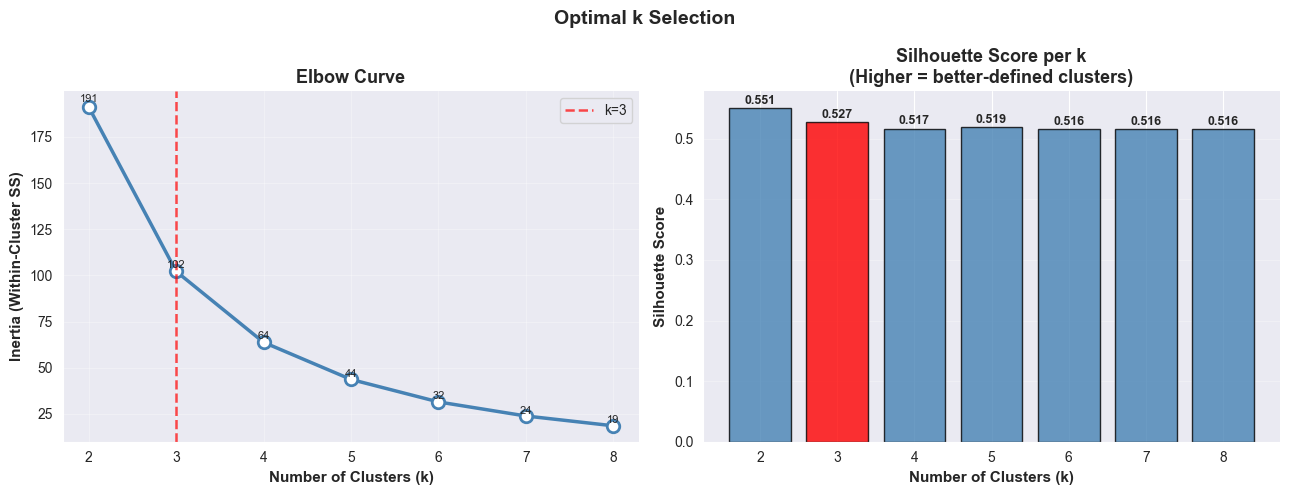

Best k by silhouette: 2
Silhouette at k=3:    0.5273


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow curve
ax1 = axes[0]
ax1.plot(list(k_range), inertias, 'o-', linewidth=2.5, markersize=9,
         color='steelblue', markerfacecolor='white', markeredgewidth=2)
ax1.axvline(x=3, color='red', linestyle='--', linewidth=1.8, alpha=0.7, label='k=3')
ax1.set_xlabel('Number of Clusters (k)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Inertia (Within-Cluster SS)', fontsize=11, fontweight='bold')
ax1.set_title('Elbow Curve', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)
for k, inertia in zip(k_range, inertias):
    ax1.text(k, inertia * 1.01, f'{inertia:,.0f}', ha='center', va='bottom', fontsize=8)

# Silhouette scores
ax2 = axes[1]
colors_sil = ['red' if k == 3 else 'steelblue' for k in k_range]
bars = ax2.bar(list(k_range), silhouette_scores, color=colors_sil, edgecolor='black', alpha=0.8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Silhouette Score', fontsize=11, fontweight='bold')
ax2.set_title('Silhouette Score per k\n(Higher = better-defined clusters)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)
for k, sil in zip(k_range, silhouette_scores):
    ax2.text(k, sil + 0.002, f'{sil:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Optimal k Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_k_sil = list(k_range)[np.argmax(silhouette_scores)]
print(f'Best k by silhouette: {best_k_sil}')
print(f'Silhouette at k=3:    {silhouette_scores[1]:.4f}')

## Step 4: Fit K-Means (k=3)

In [19]:
K = 3

# Determine data to cluster on (prefer risk_score if present)
if 'risk_score' in features.columns:
    risk_numeric = pd.to_numeric(features.loc[X.index, 'risk_score'], errors='coerce')
    if risk_numeric.isna().all():
        data_for_k = X_pca
    else:
        data_for_k = risk_numeric.values.reshape(-1, 1)
else:
    data_for_k = X_pca

kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=20)
cluster_labels = kmeans.fit_predict(data_for_k)

print(f'✓ K-Means fitted (k={K}, n_init=20)')
print(f'  Final inertia: {kmeans.inertia_:,.2f}')
print(f'  Iterations:    {kmeans.n_iter_}')
print(f'\nCluster sizes:')
unique, counts = np.unique(cluster_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c:,} segments ({c/len(cluster_labels):.1%})')

✓ K-Means fitted (k=3, n_init=20)
  Final inertia: 102.14
  Iterations:    5

Cluster sizes:
  Cluster 0: 12,166 segments (33.8%)
  Cluster 1: 16,518 segments (45.9%)
  Cluster 2: 7,294 segments (20.3%)


## Step 5: Order Clusters → Assign Risk Labels

K-Means cluster IDs are arbitrary. We order them by **mean PC1 score** (the dominant component, explaining ~33% of variance) and assign low / medium / high accordingly.

We also verify this ordering against the mean raw risk score from the original data.

In [20]:
# Build result dataframe
result_df = features.loc[X.index].copy().reset_index(drop=True)
result_df['cluster_id'] = cluster_labels
result_df['pc1_score'] = X_pca[:, 0]

# Compute mean PC1 per cluster
cluster_pc1_means = result_df.groupby('cluster_id')['pc1_score'].mean()

# Also check mean raw risk_score if column exists and is numeric
if 'risk_score' in result_df.columns:
    risk_numeric = pd.to_numeric(result_df['risk_score'], errors='coerce')
    cluster_risk_means = risk_numeric.groupby(result_df['cluster_id']).mean()
else:
    cluster_risk_means = None

print('Cluster PC1 means (higher PC1 → different spatial character):')
print(cluster_pc1_means.sort_values())

# Order clusters: prefer ordering by mean raw risk_score when available, else by PC1 mean
if cluster_risk_means is not None and not cluster_risk_means.isna().all():
    ordered_clusters = cluster_risk_means.sort_values().index.tolist()
else:
    ordered_clusters = cluster_pc1_means.sort_values().index.tolist()

risk_map = {
    ordered_clusters[0]: 'low',
    ordered_clusters[1]: 'medium',
    ordered_clusters[2]: 'high'
}

result_df['risk_class'] = result_df['cluster_id'].map(risk_map)

print('\nCluster → Risk Class mapping:')
for cid, label in risk_map.items():
    n = (result_df['cluster_id'] == cid).sum()
    pc1 = cluster_pc1_means[cid]
    print(f'  Cluster {cid} → {label:6s}  (mean PC1={pc1:.3f}, n={n:,})')

if cluster_risk_means is not None:
    print('\nCross-check — mean raw risk_score per assigned class:')
    for cid, label in risk_map.items():
        print(f'  {label:6s}: mean risk_score = {cluster_risk_means[cid]:.4f}')

Cluster PC1 means (higher PC1 → different spatial character):
cluster_id
2   -1.1245
1    0.0184
0    0.6493
Name: pc1_score, dtype: float64

Cluster → Risk Class mapping:
  Cluster 0 → low     (mean PC1=0.649, n=12,166)
  Cluster 1 → medium  (mean PC1=0.018, n=16,518)
  Cluster 2 → high    (mean PC1=-1.125, n=7,294)

Cross-check — mean raw risk_score per assigned class:
  low   : mean risk_score = 0.3538
  medium: mean risk_score = 0.4951
  high  : mean risk_score = 0.6504


## Step 6: Cluster Summary Statistics

In [21]:
print('='*70)
print('CLUSTER PROFILE — Mean Feature Values per Risk Class')
print('='*70)

cluster_profile = result_df.groupby('risk_class')[FEATURE_COLS].mean()
cluster_profile.columns = [clean_name(c) for c in cluster_profile.columns]
cluster_profile = cluster_profile.loc[['low', 'medium', 'high']]
print(cluster_profile.round(4))

print('\n' + '='*70)
print('CLUSTER SIZES')
print('='*70)
size_summary = result_df['risk_class'].value_counts().reindex(['low', 'medium', 'high'])
for label, count in size_summary.items():
    pct = count / len(result_df) * 100
    bar = '█' * int(pct / 2)
    print(f'  {label:6s}: {count:6,} segments ({pct:5.1f}%)  {bar}')

CLUSTER PROFILE — Mean Feature Values per Risk Class
            Lighting  Visibility  Connectivity  Enclosure  Land Use Score  \
risk_class                                                                  
low           0.0178      0.6869        0.6326     0.1761          0.3275   
medium        0.0113      0.6048        0.5159     0.2561          0.2919   
high          0.0072      0.4756        0.3950     0.3712          0.3199   

            Transport Proximity  
risk_class                       
low                      0.1408  
medium                   0.2147  
high                     0.2844  

CLUSTER SIZES
  low   : 12,166 segments ( 33.8%)  ████████████████
  medium: 16,518 segments ( 45.9%)  ██████████████████████
  high  :  7,294 segments ( 20.3%)  ██████████


## Step 7: Visualizations

### 7.1 Clusters in PCA Space (PC1 vs PC2)

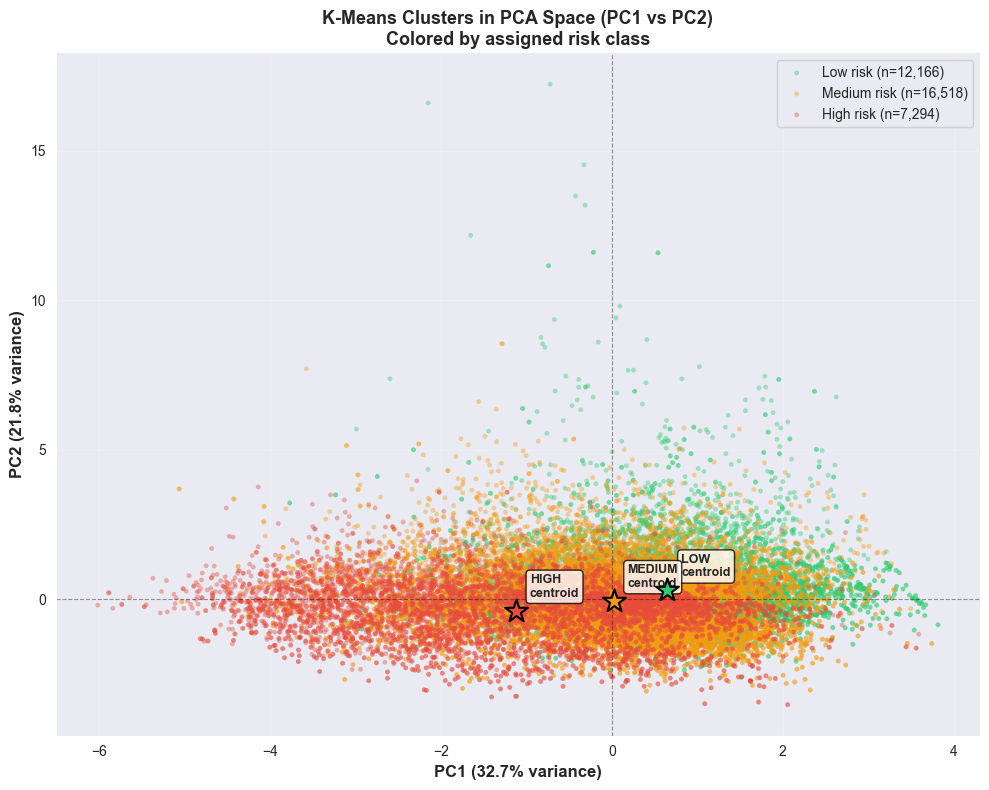

In [23]:
RISK_COLORS = {'low': '#2ecc71', 'medium': '#f39c12', 'high': '#e74c3c'}

fig, ax = plt.subplots(figsize=(10, 8))

for risk_level in ['low', 'medium', 'high']:
    mask = result_df['risk_class'] == risk_level
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=RISK_COLORS[risk_level],
        label=f'{risk_level.capitalize()} risk (n={mask.sum():,})',
        alpha=0.4, s=12, edgecolors='none'
    )

# Plot cluster centroids in PCA space
# If KMeans was fit on PCA-space, cluster_centers_ are already in PCA coordinates.
# If KMeans was fit on 1D risk_score, compute centroids in PCA space as the mean PC coords per cluster.
try:
    used_pca_space = (data_for_k is X_pca) or (hasattr(data_for_k, 'shape') and data_for_k.shape[1] == X_pca.shape[1])
except Exception:
    used_pca_space = False

if used_pca_space:
    centroids_pca = kmeans.cluster_centers_
else:
    centroids_pca = np.zeros((K, X_pca.shape[1]))
    for cid in range(K):
        mask = cluster_labels == cid
        if mask.sum() > 0:
            centroids_pca[cid] = X_pca[mask].mean(axis=0)
        else:
            centroids_pca[cid] = np.nan

for cid, label in risk_map.items():
    # guard against cases where PCA has <2 components or centroid is NaN
    if centroids_pca.shape[1] < 2 or np.isnan(centroids_pca[cid, 0]) or np.isnan(centroids_pca[cid, 1]):
        continue
    ax.scatter(
        centroids_pca[cid, 0], centroids_pca[cid, 1],
        c=RISK_COLORS[label], s=300, marker='*',
        edgecolors='black', linewidth=1.5, zorder=5
    )
    ax.annotate(
        f'{label.upper()}\ncentroid',
        (centroids_pca[cid, 0], centroids_pca[cid, 1]),
        textcoords='offset points', xytext=(10, 10),
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, ec='black')
    )

ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.4)
ax.axvline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.4)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_title('K-Means Clusters in PCA Space (PC1 vs PC2)\nColored by assigned risk class', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 7.2 Silhouette Plot (k=3)

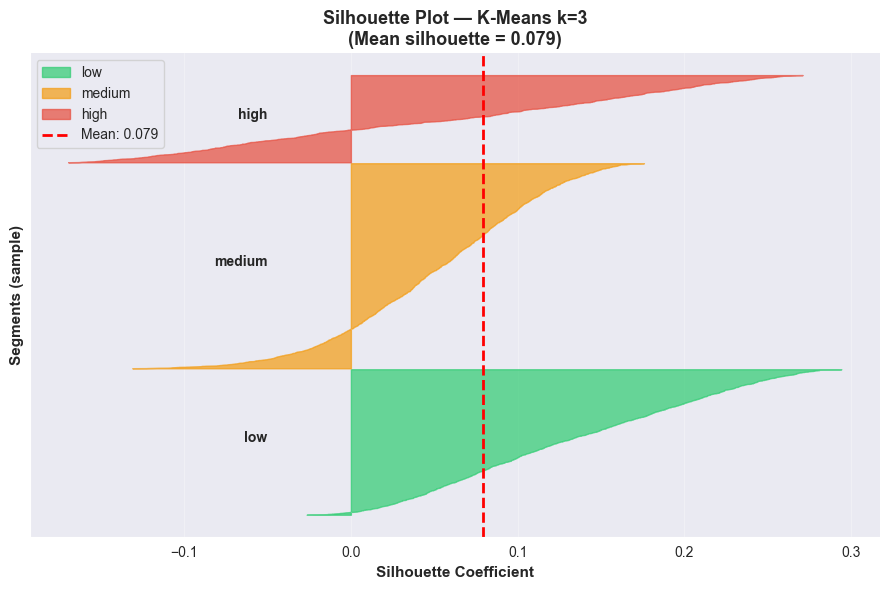

In [24]:
# Compute silhouette values per sample (subsample for speed)
sample_size = min(5000, len(X_pca))
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_pca), size=sample_size, replace=False)

X_sample = X_pca[sample_idx]
labels_sample = cluster_labels[sample_idx]
sil_values = silhouette_samples(X_sample, labels_sample)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10

risk_order = ['low', 'medium', 'high']
for risk_level in risk_order:
    cid = [k for k, v in risk_map.items() if v == risk_level][0]
    cluster_sil = sil_values[labels_sample == cid]
    cluster_sil.sort()
    size = len(cluster_sil)
    y_upper = y_lower + size
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, cluster_sil,
        alpha=0.7, color=RISK_COLORS[risk_level],
        label=risk_level
    )
    ax.text(-0.05, (y_lower + y_upper) / 2, risk_level, ha='right', fontsize=10, fontweight='bold')
    y_lower = y_upper + 10

avg_sil = silhouette_score(X_sample, labels_sample)
ax.axvline(avg_sil, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=11, fontweight='bold')
ax.set_ylabel('Segments (sample)', fontsize=11, fontweight='bold')
ax.set_title(f'Silhouette Plot — K-Means k=3\n(Mean silhouette = {avg_sil:.3f})', fontsize=13, fontweight='bold')
ax.set_yticks([])
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 7.3 Feature Profiles per Risk Class (Radar / Bar)

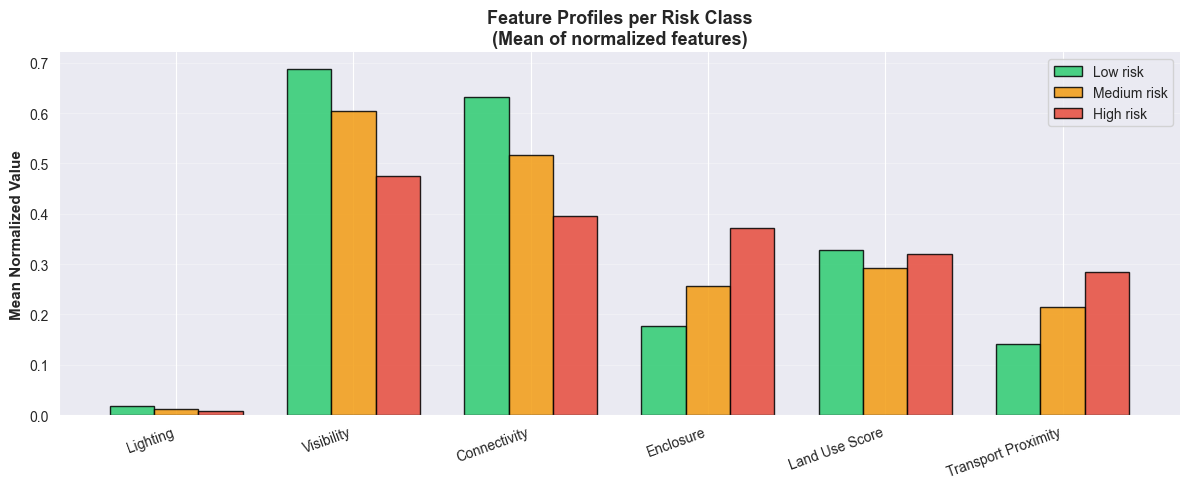

In [25]:
profile = result_df.groupby('risk_class')[FEATURE_COLS].mean().loc[['low', 'medium', 'high']]
display_cols = [clean_name(c) for c in FEATURE_COLS]
profile.columns = display_cols

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(display_cols))
width = 0.25

for i, (risk_level, color) in enumerate(RISK_COLORS.items()):
    ax.bar(x + i * width, profile.loc[risk_level], width,
           label=f'{risk_level.capitalize()} risk', color=color, edgecolor='black', alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(display_cols, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Mean Normalized Value', fontsize=11, fontweight='bold')
ax.set_title('Feature Profiles per Risk Class\n(Mean of normalized features)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 7.4 Risk Class Distribution

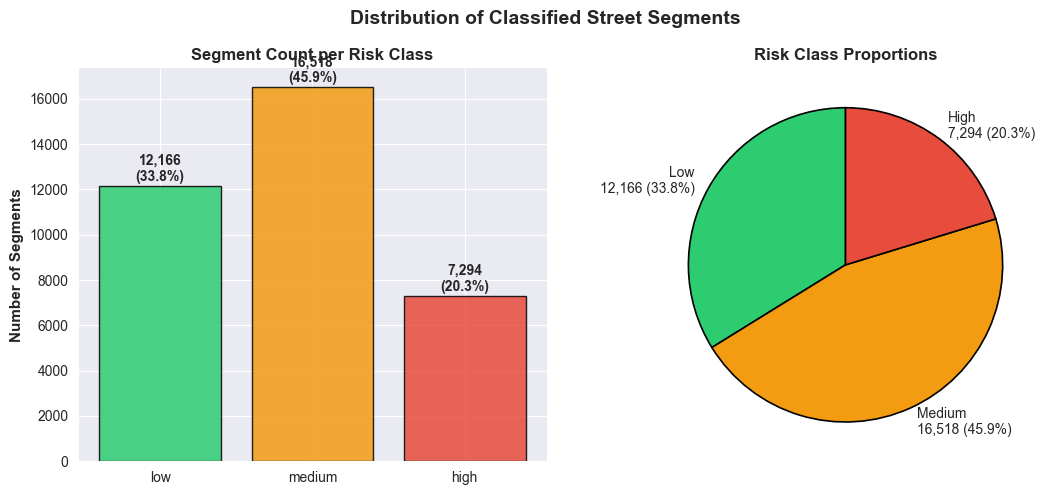

In [26]:
counts = result_df['risk_class'].value_counts().reindex(['low', 'medium', 'high'])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Bar chart
ax1 = axes[0]
colors_list = [RISK_COLORS[r] for r in counts.index]
bars = ax1.bar(counts.index, counts.values, color=colors_list, edgecolor='black', alpha=0.85)
for bar, (label, count) in zip(bars, counts.items()):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
             f'{count:,}\n({count/len(result_df):.1%})',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_ylabel('Number of Segments', fontsize=11, fontweight='bold')
ax1.set_title('Segment Count per Risk Class', fontsize=12, fontweight='bold')
ax1.spines[['top', 'right']].set_visible(False)

# Pie chart
ax2 = axes[1]
ax2.pie(
    counts.values,
    labels=[f'{l.capitalize()}\n{v:,} ({v/len(result_df):.1%})' for l, v in counts.items()],
    colors=colors_list,
    autopct='',
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.2}
)
ax2.set_title('Risk Class Proportions', fontsize=12, fontweight='bold')

plt.suptitle('Distribution of Classified Street Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8: Export Results

In [27]:
output_path = r'C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\segment_risk_classified.csv'

# Keep original columns + new classification columns
export_cols = list(features.columns) + ['risk_class', 'cluster_id', 'pc1_score']
export_cols = [c for c in export_cols if c in result_df.columns]  # safety check

result_df[export_cols].to_csv(output_path, index=False)
print(f'✓ Exported {len(result_df):,} classified segments to:')
print(f'  {output_path}')
print(f'\nColumns added: risk_class, cluster_id, pc1_score')
print('\nSample output:')
print(result_df[['risk_class', 'cluster_id', 'pc1_score'] + FEATURE_COLS[:3]].head(10))

✓ Exported 35,978 classified segments to:
  C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\segment_risk_classified.csv

Columns added: risk_class, cluster_id, pc1_score

Sample output:
  risk_class  cluster_id  pc1_score  lighting_norm  visibility_norm  \
0     medium           1    -1.5936         0.0000           0.3959   
1     medium           1    -1.6326         0.0000           0.3622   
2     medium           1    -0.0237         0.0726           0.6271   
3     medium           1    -0.2936         0.0422           0.6174   
4        low           0    -0.2091         0.0252           0.5878   
5        low           0    -0.7539         0.0430           0.5789   
6     medium           1    -0.6730         0.0128           0.5378   
7        low           0    -0.2091         0.0252           0.5878   
8     medium           1     0.1677         0.0268           0.6086   
9     medium           1     0.4181         0.0176           0.6078   

   connectivity_nor

## Summary

| Step | Details |
|------|---------|
| Features | 6 normalized spatial features |
| Preprocessing | StandardScaler (mean=0, std=1) |
| Dimensionality reduction | PCA (5 components, ~96% variance) |
| Clustering | K-Means, k=3, n_init=20 |
| k justification | Elbow curve + silhouette score |
| Label assignment | Ordered by mean PC1 score per cluster |
| Output | `segment_risk_classified.csv` with `risk_class` column |

**Next step:** Use `risk_class` in the mapping notebook to visualize low/medium/high on OSM street segments.